In [1]:
"""
Interactive H-R diagram stellar evolution demo for Jupyter Lab.

This module implements a widget-driven H-R diagram using matplotlib + ipywidgets.
It keeps the more detailed physical comments and equation explanations from the
earlier draft, while also providing a cleaner, more robust public interface.

Modeling philosophy
-------------------
This is an *intermediate*, semi-empirical stellar-evolution model. It is not a
precision stellar-evolution code and does not use precomputed stellar tracks.
Instead, it uses a piecewise approximation designed to reproduce the correct
qualitative motion of stars on the H-R diagram:

- stars begin on the main sequence at cosmic time t = 0,
- more massive stars start hotter and more luminous,
- more massive stars evolve faster,
- stars brighten slightly on the main sequence,
- they then move toward the subgiant / red giant region,
- lower/intermediate-mass stars eventually appear on a white-dwarf cooling track,
- the cluster turnoff mass decreases as the population ages.

The approximation follows the planning discussion in chat, including the key
scaling relations:

1. Zero-age main-sequence luminosity

       L_ZAMS ~ M^4            for 0.8 <= M < 2
       L_ZAMS ~ 1.5 M^3.5      for 2   <= M <= 8

2. Zero-age main-sequence radius

       R_ZAMS ~ M^0.8          for 0.8 <= M < 1.5
       R_ZAMS ~ M^0.57         for 1.5 <= M <= 8

3. Zero-age main-sequence effective temperature from the
   Stefan-Boltzmann relation in solar-normalized form:

       L = 4 pi R^2 sigma T^4

   therefore

       T / T_sun = (L / R^2)^(1/4)

   We intentionally derive T from L and R rather than imposing a separate
   T ~ M^beta law, because that keeps the adopted luminosity and radius
   scalings internally consistent.

4. Main-sequence lifetime from a simple fuel / burn-rate argument:

       t_MS ~ available fuel / burn rate ~ M / L

   and with the normalization used here:

       t_MS ~= 1e4 * M / L     [Myr]

   which gives ~10 Gyr for a 1 Msun star and much shorter lifetimes for
   more massive stars.

5. Later phase durations are expressed as fractions of t_MS:

       t_SG  = 0.08 t_MS
       t_RGB = 0.06 t_MS
       t_He  = 0.10 t_MS
       t_AGB = 0.03 t_MS

   These fractions are pedagogical approximations chosen to give smooth,
   visually plausible motion on the H-R diagram.

Recommended Jupyter usage
-------------------------
In Jupyter Lab / Notebook, do:

    %matplotlib widget

    from hr_evolution_widget_polished import build_hr_widget_demo
    ui = build_hr_widget_demo()
    display(ui)

The %matplotlib widget backend is important for live in-place figure updates.
That backend typically requires ipympl in the kernel environment:

    pip install ipympl

The module also provides static snapshot helpers, which are useful for testing:

    from hr_evolution_widget_polished import build_population, draw_snapshot
    pop = build_population()
    fig, ax = draw_snapshot(pop, age_myr=1000.0)

"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Iterable

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap
import ipywidgets as widgets


# -----------------------------------------------------------------------------
# Physical / numerical constants
# -----------------------------------------------------------------------------
SUN_T_EFF = 5772.0  # K
SECONDS_PER_YEAR = 365.25 * 24.0 * 3600.0
MYR_TO_YEAR = 1.0e6


# -----------------------------------------------------------------------------
# Data containers
# -----------------------------------------------------------------------------
@dataclass
class ClusterPopulation:
    """Synthetic coeval stellar population.

    Attributes
    ----------
    mass : ndarray
        Initial stellar masses in solar units.
    l_zams : ndarray
        Approximate zero-age main-sequence luminosities in solar units.
    r_zams : ndarray
        Approximate zero-age main-sequence radii in solar units.
    t_zams : ndarray
        Approximate zero-age main-sequence effective temperatures in K.
    t_ms, t_sg, t_rgb, t_he, t_agb : ndarray
        Approximate durations of the adopted evolutionary phases, in Myr.
    sn_threshold_mass : float
        Stars with masses >= this threshold are not sent to the white-dwarf
        branch in this simplified model. Instead, they are treated as terminal
        / faded after the last giant-like phase.
    """

    mass: np.ndarray
    l_zams: np.ndarray
    r_zams: np.ndarray
    t_zams: np.ndarray
    t_ms: np.ndarray
    t_sg: np.ndarray
    t_rgb: np.ndarray
    t_he: np.ndarray
    t_agb: np.ndarray
    sn_threshold_mass: float


@dataclass
class StarState:
    """Instantaneous stellar state for the whole population at one cosmic age."""

    teff: np.ndarray
    lum: np.ndarray
    radius: np.ndarray
    phase_code: np.ndarray
    visible: np.ndarray


# -----------------------------------------------------------------------------
# Evolution phase codes
# -----------------------------------------------------------------------------
PHASE_MAIN_SEQUENCE = 0
PHASE_SUBGIANT = 1
PHASE_RED_GIANT = 2
PHASE_HE_BURNING = 3
PHASE_AGB = 4
PHASE_WHITE_DWARF = 5
PHASE_TERMINAL = 6

PHASE_NAMES = {
    PHASE_MAIN_SEQUENCE: "Main sequence",
    PHASE_SUBGIANT: "Subgiant",
    PHASE_RED_GIANT: "Red giant",
    PHASE_HE_BURNING: "He-burning-like",
    PHASE_AGB: "Late giant / AGB-like",
    PHASE_WHITE_DWARF: "White dwarf",
    PHASE_TERMINAL: "Terminal / faded",
}


# -----------------------------------------------------------------------------
# Small utility helpers
# -----------------------------------------------------------------------------
def smoothstep(u: np.ndarray) -> np.ndarray:
    """Return the smooth interpolation function 3u^2 - 2u^3.

    We use this repeatedly to avoid visibly sharp corners when stars move from
    one phase to the next. In other words, the *model* is piecewise, but the
    plotted motion should still look smooth.
    """
    uc = np.clip(u, 0.0, 1.0)
    return uc * uc * (3.0 - 2.0 * uc)


def log_interp(log_a: np.ndarray, log_b: np.ndarray, u: np.ndarray) -> np.ndarray:
    """Smooth interpolation between two logarithmic endpoints."""
    s = smoothstep(u)
    return log_a + (log_b - log_a) * s


def clip_positive(x: np.ndarray, floor: float) -> np.ndarray:
    """Clip values to stay positive and above a small numerical floor."""
    return np.maximum(x, floor)


def format_age_label(age_myr: float) -> str:
    """Format age in Myr or Gyr depending on magnitude."""
    if age_myr < 1000.0:
        return f"Age = {age_myr:,.0f} Myr"
    return f"Age = {age_myr / 1000.0:,.2f} Gyr"


def compute_speedup(age_max_myr: float, playback_duration_s: float) -> tuple[float, float]:
    """Return (Myr/s, real-time speedup factor)."""
    myr_per_s = age_max_myr / playback_duration_s
    speedup = myr_per_s * MYR_TO_YEAR * SECONDS_PER_YEAR
    return myr_per_s, speedup


# -----------------------------------------------------------------------------
# Synthetic population construction
# -----------------------------------------------------------------------------
def sample_masses_imf(
    n_stars: int,
    m_min: float = 0.8,
    m_max: float = 8.0,
    alpha: float = 2.35,
    random_seed: int | None = 0,
) -> np.ndarray:
    """Sample stellar masses from a truncated Salpeter-like IMF.

    We adopt

        dN/dM ~ M^{-alpha}

    with alpha ~= 2.35. This is a simple way to generate many more low-mass than
    high-mass stars while staying within a teaching-level model.
    """
    rng = np.random.default_rng(random_seed)
    u = rng.uniform(size=n_stars)

    if np.isclose(alpha, 1.0):
        masses = m_min * (m_max / m_min) ** u
    else:
        one_minus_alpha = 1.0 - alpha
        a = m_min ** one_minus_alpha
        b = m_max ** one_minus_alpha
        masses = (a + (b - a) * u) ** (1.0 / one_minus_alpha)

    return np.sort(masses)


def zams_luminosity(mass: np.ndarray) -> np.ndarray:
    """Approximate ZAMS luminosity in solar units.

    Piecewise first-approximation law used in the planning stage:

        L_ZAMS ~ M^4           for 0.8 <= M < 2
        L_ZAMS ~ 1.5 M^3.5     for 2 <= M <= 8

    This captures the steep increase of luminosity with mass without trying to
    reproduce detailed stellar-model tables.
    """
    lum = np.empty_like(mass)
    low = mass < 2.0
    high = ~low
    lum[low] = mass[low] ** 4.0
    lum[high] = 1.5 * mass[high] ** 3.5
    return lum


def zams_radius(mass: np.ndarray) -> np.ndarray:
    """Approximate ZAMS radius in solar units.

    Piecewise first-approximation law used in the planning stage:

        R_ZAMS ~ M^0.8         for 0.8 <= M < 1.5
        R_ZAMS ~ M^0.57        for 1.5 <= M <= 8

    This is used both for marker sizing and for deriving a self-consistent
    effective temperature from the Stefan-Boltzmann relation.
    """
    radius = np.empty_like(mass)
    low = mass < 1.5
    high = ~low
    radius[low] = mass[low] ** 0.8
    radius[high] = mass[high] ** 0.57
    return radius


def zams_temperature(l_zams: np.ndarray, r_zams: np.ndarray) -> np.ndarray:
    """Approximate ZAMS effective temperature in K.

    In solar-normalized form, the Stefan-Boltzmann relation gives

        L / L_sun = (R / R_sun)^2 (T / T_sun)^4

    hence

        T = T_sun * (L / R^2)^(1/4)

    We deliberately use this relation rather than imposing an independent
    T ~ M^beta law, because it keeps the adopted L(M) and R(M) scalings mutually
    consistent.
    """
    return SUN_T_EFF * (l_zams / (r_zams ** 2.0)) ** 0.25


def build_population(
    n_stars: int = 200,
    m_min: float = 0.8,
    m_max: float = 8.0,
    random_seed: int | None = 0,
    sn_threshold_mass: float = 8.0,
) -> ClusterPopulation:
    """Build a synthetic coeval stellar population.

    All stars are assumed to form at t = 0 and start on the main sequence.

    The main-sequence lifetime is normalized as

        t_MS ~= 1e4 * M / L    [Myr]

    motivated by a fuel / burn-rate argument. Later phase durations are modeled
    as fixed fractions of t_MS, following the earlier design discussion.
    """
    mass = sample_masses_imf(
        n_stars=n_stars,
        m_min=m_min,
        m_max=m_max,
        alpha=2.35,
        random_seed=random_seed,
    )

    l_zams = zams_luminosity(mass)
    r_zams = zams_radius(mass)
    t_zams = zams_temperature(l_zams, r_zams)

    # t_MS ~ M/L, with the 1 Msun normalization chosen so that a solar-mass star
    # lives about 10 Gyr on the main sequence.
    t_ms = 1.0e4 * mass / l_zams

    # Later phases are pedagogical fractions of t_MS rather than detailed models.
    t_sg = 0.08 * t_ms
    t_rgb = 0.06 * t_ms
    t_he = 0.10 * t_ms
    t_agb = 0.03 * t_ms

    return ClusterPopulation(
        mass=mass,
        l_zams=l_zams,
        r_zams=r_zams,
        t_zams=t_zams,
        t_ms=t_ms,
        t_sg=t_sg,
        t_rgb=t_rgb,
        t_he=t_he,
        t_agb=t_agb,
        sn_threshold_mass=sn_threshold_mass,
    )


# -----------------------------------------------------------------------------
# Piecewise semi-empirical stellar evolution model
# -----------------------------------------------------------------------------
def evaluate_population(pop: ClusterPopulation, age_myr: float) -> StarState:
    """Evaluate all stars at one global cosmic age.

    Notes on the adopted phase prescriptions
    ---------------------------------------
    The formulas below are chosen to make the H-R motion physically plausible
    while remaining simple enough for teaching use.

    Main sequence:
        Stars brighten modestly while staying near the main sequence.
        We model this by a small increase in log L and only a very small drift
        in log T over the interval 0 <= t < t_MS.

    Subgiant phase:
        After hydrogen exhaustion in the core, luminosity rises and the star
        cools somewhat. On the H-R diagram this sends the star upward and to the
        right.

    Red giant branch:
        Luminosity rises strongly, while T_eff drops toward roughly 3500-4500 K.
        This creates the dramatic excursion toward the upper-right.

    He-burning-like phase:
        The model then moves the star somewhat leftward (hotter) and slightly
        downward relative to the RGB tip. This is a simplified pedagogical stand-
        in for the fact that stars do not simply remain frozen at the RGB tip.

    Late giant / AGB-like phase:
        Another move toward cooler and somewhat more luminous states.

    White dwarf cooling:
        Stars below the chosen terminal threshold are moved to a hot but faint
        white-dwarf birth point, then allowed to cool and fade. This sends them
        down and to the right on the H-R diagram.

    Terminal high-mass stars:
        Rather than attempting a detailed supernova / compact remnant model, we
        simply fade them after the last giant-like phase.
    """
    m = pop.mass
    n = m.size

    teff = np.empty(n, dtype=float)
    lum = np.empty(n, dtype=float)
    radius = np.empty(n, dtype=float)
    phase_code = np.empty(n, dtype=int)
    visible = np.ones(n, dtype=bool)

    log_l_z = np.log10(pop.l_zams)
    log_t_z = np.log10(pop.t_zams)

    # Main-sequence brightening and temperature drift.
    # These are intentionally mild: real stars do not run wildly across the
    # H-R diagram during the main sequence.
    delta_log_l_ms = 0.18 + 0.08 * np.tanh((m - 1.2) / 0.8)
    delta_log_t_ms = 0.015 * np.tanh((m - 1.0) / 1.5)

    # Phase boundaries.
    t0 = np.zeros_like(pop.t_ms)
    t1 = pop.t_ms
    t2 = t1 + pop.t_sg
    t3 = t2 + pop.t_rgb
    t4 = t3 + pop.t_he
    t5 = t4 + pop.t_agb

    age = np.full(n, age_myr, dtype=float)

    # ---- Main sequence ------------------------------------------------------
    ms = age < t1
    if np.any(ms):
        u = (age[ms] - t0[ms]) / pop.t_ms[ms]
        log_l = log_l_z[ms] + delta_log_l_ms[ms] * smoothstep(u)
        log_t = log_t_z[ms] + delta_log_t_ms[ms] * smoothstep(u)

        lum_ms = 10.0 ** log_l
        teff_ms = 10.0 ** log_t
        radius_ms = np.sqrt(lum_ms / ((teff_ms / SUN_T_EFF) ** 4.0))

        lum[ms] = lum_ms
        teff[ms] = teff_ms
        radius[ms] = radius_ms
        phase_code[ms] = PHASE_MAIN_SEQUENCE

    # End-of-main-sequence values for continuity.
    log_l_tams = log_l_z + delta_log_l_ms
    log_t_tams = log_t_z + delta_log_t_ms

    # ---- Subgiant -----------------------------------------------------------
    sg = (age >= t1) & (age < t2)
    if np.any(sg):
        u = (age[sg] - t1[sg]) / pop.t_sg[sg]

        # From the planning stage:
        #   log L increases by ~0.35 dex,
        #   log T decreases by ~0.10 dex.
        log_l = log_interp(log_l_tams[sg], log_l_tams[sg] + 0.35, u)
        log_t = log_interp(log_t_tams[sg], log_t_tams[sg] - 0.10, u)

        lum_sg = 10.0 ** log_l
        teff_sg = 10.0 ** log_t
        radius_sg = np.sqrt(lum_sg / ((teff_sg / SUN_T_EFF) ** 4.0))

        lum[sg] = lum_sg
        teff[sg] = teff_sg
        radius[sg] = radius_sg
        phase_code[sg] = PHASE_SUBGIANT

    log_l_sg_end = log_l_tams + 0.35
    log_t_sg_end = log_t_tams - 0.10

    # ---- Red giant branch ---------------------------------------------------
    rgb = (age >= t2) & (age < t3)

    # Weak mass dependence of the RGB tip temperature, clipped to the intended
    # pedagogical range 3500-4500 K.
    rgb_tip_teff = 4300.0 - 350.0 * np.tanh((m - 2.0) / 2.0)
    rgb_tip_teff = np.clip(rgb_tip_teff, 3500.0, 4500.0)
    rgb_tip_log_t = np.log10(rgb_tip_teff)

    # Luminosity rise along the RGB: roughly 1.1-1.5 dex.
    delta_log_l_rgb = 1.20 + 0.30 * np.tanh((m - 2.0) / 2.0)

    if np.any(rgb):
        u = (age[rgb] - t2[rgb]) / pop.t_rgb[rgb]
        log_l = log_interp(log_l_sg_end[rgb], log_l_sg_end[rgb] + delta_log_l_rgb[rgb], u)
        log_t = log_interp(log_t_sg_end[rgb], rgb_tip_log_t[rgb], u)

        lum_rgb = 10.0 ** log_l
        teff_rgb = 10.0 ** log_t
        radius_rgb = np.sqrt(lum_rgb / ((teff_rgb / SUN_T_EFF) ** 4.0))

        lum[rgb] = lum_rgb
        teff[rgb] = teff_rgb
        radius[rgb] = radius_rgb
        phase_code[rgb] = PHASE_RED_GIANT

    log_l_rgb_tip = log_l_sg_end + delta_log_l_rgb
    log_t_rgb_tip = rgb_tip_log_t

    # ---- He-burning-like phase ---------------------------------------------
    he = (age >= t3) & (age < t4)
    if np.any(he):
        u = (age[he] - t3[he]) / pop.t_he[he]
        s = smoothstep(u)

        # Simple phenomenological path:
        #   move slightly down from RGB-tip luminosity,
        #   move somewhat leftward (hotter),
        #   with a small residual upward luminosity trend within the phase.
        log_l = log_l_rgb_tip[he] - 0.25 * s + 0.10 * u
        log_t = log_t_rgb_tip[he] + 0.10 * s

        lum_he = 10.0 ** log_l
        teff_he = 10.0 ** log_t
        radius_he = np.sqrt(lum_he / ((teff_he / SUN_T_EFF) ** 4.0))

        lum[he] = lum_he
        teff[he] = teff_he
        radius[he] = radius_he
        phase_code[he] = PHASE_HE_BURNING

    log_l_he_end = log_l_rgb_tip - 0.25 + 0.10
    log_t_he_end = log_t_rgb_tip + 0.10

    # ---- Late giant / AGB-like phase ---------------------------------------
    agb = (age >= t4) & (age < t5)
    if np.any(agb):
        u = (age[agb] - t4[agb]) / pop.t_agb[agb]
        log_l = log_interp(log_l_he_end[agb], log_l_he_end[agb] + 0.50, u)
        log_t = log_interp(log_t_he_end[agb], log_t_he_end[agb] - 0.08, u)

        lum_agb = 10.0 ** log_l
        teff_agb = 10.0 ** log_t
        radius_agb = np.sqrt(lum_agb / ((teff_agb / SUN_T_EFF) ** 4.0))

        lum[agb] = lum_agb
        teff[agb] = teff_agb
        radius[agb] = radius_agb
        phase_code[agb] = PHASE_AGB

    log_l_agb_end = log_l_he_end + 0.50
    log_t_agb_end = log_t_he_end - 0.08

    # ---- White-dwarf branch -------------------------------------------------
    post_agb = age >= t5
    wd = post_agb & (m < pop.sn_threshold_mass)
    if np.any(wd):
        # Post-AGB elapsed time normalized by t_MS so higher-mass stars progress
        # more quickly in global age than lower-mass stars.
        tau = clip_positive((age[wd] - t5[wd]) / pop.t_ms[wd], 0.0)
        u = tau / (1.0 + tau)  # maps [0, inf) -> [0, 1)

        # White-dwarf birth point chosen during the planning stage.
        log_t_wd0 = np.log10(25000.0)
        log_l_wd0 = np.log10(0.01)

        log_t = log_t_wd0 - 0.25 * u
        log_l = log_l_wd0 - 1.20 * u

        lum_wd = 10.0 ** log_l
        teff_wd = 10.0 ** log_t

        # White dwarfs are physically small. Keep them visible but not dominant.
        radius_wd = np.full(np.count_nonzero(wd), 0.012)

        lum[wd] = lum_wd
        teff[wd] = teff_wd
        radius[wd] = radius_wd
        phase_code[wd] = PHASE_WHITE_DWARF

    # ---- Terminal faded objects --------------------------------------------
    terminal = post_agb & (m >= pop.sn_threshold_mass)
    if np.any(terminal):
        lum[terminal] = 10.0 ** log_l_agb_end[terminal]
        teff[terminal] = 10.0 ** log_t_agb_end[terminal]
        radius[terminal] = np.sqrt(lum[terminal] / ((teff[terminal] / SUN_T_EFF) ** 4.0))
        phase_code[terminal] = PHASE_TERMINAL
        visible[terminal] = False

    teff = clip_positive(teff, 1000.0)
    lum = clip_positive(lum, 1e-8)
    radius = clip_positive(radius, 1e-3)

    return StarState(
        teff=teff,
        lum=lum,
        radius=radius,
        phase_code=phase_code,
        visible=visible,
    )


# -----------------------------------------------------------------------------
# Visualization helpers
# -----------------------------------------------------------------------------
def marker_sizes_from_radius(radius: np.ndarray, marker_scale: float = 1.0) -> np.ndarray:
    """Convert physical radius to visually useful scatter-marker areas.

    A linear size mapping would make giant stars enormous and visually overwhelm
    the plot. We therefore compress the dynamic range using a sublinear power law.

    White dwarfs are physically tiny, so we keep them visible with a minimum size.
    """
    sizes = 18.0 + 38.0 * np.power(radius, 0.45)
    is_wd = radius < 0.05
    sizes[is_wd] = 14.0
    return sizes * marker_scale


def colors_from_temperature(teff: np.ndarray) -> np.ndarray:
    """Map effective temperature to RGBA colors.

    This is a visualization-oriented color mapping, not a strict blackbody-color
    computation. The mapping is keyed to log10(T_eff) and reversed so hotter stars
    look bluer and cooler stars look redder.
    """
    log_t = np.log10(teff)
    norm = Normalize(vmin=np.log10(3000.0), vmax=np.log10(30000.0), clip=True)
    cmap = get_cmap("coolwarm_r")
    return cmap(norm(log_t))


def add_hr_guides(ax: Axes) -> list:
    """Add light guide labels / regions to the H-R diagram and return text artists."""
    texts = []
    texts.append(ax.text(12000, 1e4, "Main sequence", fontsize=10, alpha=0.55))
    texts.append(ax.text(4300, 2e3, "Giants", fontsize=10, alpha=0.55))
    texts.append(ax.text(14000, 3e-3, "White dwarfs", fontsize=10, alpha=0.55))
    return texts


def _visible_state_arrays(
    state: StarState,
    show_terminal_faded_stars: bool,
    marker_scale: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return plotting arrays after applying visibility rules."""
    visible = state.visible.copy()
    if show_terminal_faded_stars:
        visible[:] = True

    xy = np.column_stack([state.teff[visible], state.lum[visible]])
    sizes = marker_sizes_from_radius(state.radius, marker_scale=marker_scale)[visible]
    colors = colors_from_temperature(state.teff)
    if show_terminal_faded_stars:
        terminal_mask = state.phase_code == PHASE_TERMINAL
        colors[terminal_mask, 3] = 0.12
    colors = colors[visible]
    return visible, xy, sizes, colors, state.phase_code[visible]


def _current_turnoff_mass(pop: ClusterPopulation, age_myr: float) -> float | None:
    """Return the largest mass still on the main sequence at the given age."""
    mask = pop.t_ms > age_myr
    if not np.any(mask):
        return None
    return float(np.max(pop.mass[mask]))


def _setup_base_axes(
    ax: Axes,
    age_max_myr: float,
    playback_duration_s: float,
    show_guides: bool,
) -> list:
    """Configure H-R diagram axes and return guide text artists."""
    ax.set_yscale("log")
    ax.set_xlim(30000, 2800)  # standard H-R convention: temperature decreases rightward
    ax.set_ylim(1e-4, 5e5)
    ax.set_xlabel(r"Effective temperature $T_{\rm eff}$ [K]")
    ax.set_ylabel(r"Luminosity $L / L_\odot$")
    ax.grid(alpha=0.22, which="both")

    myr_per_s, speedup = compute_speedup(age_max_myr, playback_duration_s)
    info = (
        "Global cosmic clock\n"
        f"Playback speed ≈ {myr_per_s:,.1f} Myr/s\n"
        f"Speed-up ≈ {speedup:,.2e}"
    )
    ax.text(
        0.015,
        0.985,
        info,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", fc="white", ec="0.75", alpha=0.85),
    )

    guide_texts = add_hr_guides(ax)
    for txt in guide_texts:
        txt.set_visible(show_guides)
    return guide_texts


def draw_snapshot(
    pop: ClusterPopulation,
    age_myr: float,
    age_max_myr: float = 3000.0,
    playback_duration_s: float = 30.0,
    show_guides: bool = True,
    show_terminal_faded_stars: bool = False,
    black_marker_edges: bool = True,
    marker_scale: float = 1.0,
    fig: Figure | None = None,
    ax: Axes | None = None,
) -> tuple[Figure, Axes]:
    """Draw one static H-R snapshot at the requested cosmic age.

    This is the simplest sanity-check function and is also useful for lecture
    slides, saved figures, and debugging the physical model before dealing with
    interactivity.
    """
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(9.0, 6.8))

    _setup_base_axes(ax, age_max_myr, playback_duration_s, show_guides=show_guides)

    state = evaluate_population(pop, age_myr)
    _, xy, sizes, colors, _ = _visible_state_arrays(
        state,
        show_terminal_faded_stars=show_terminal_faded_stars,
        marker_scale=marker_scale,
    )

    edgecolors = "k" if black_marker_edges else "none"
    linewidths = 0.2 if black_marker_edges else 0.0
    ax.scatter(
        xy[:, 0],
        xy[:, 1],
        s=sizes,
        c=colors,
        edgecolors=edgecolors,
        linewidths=linewidths,
        alpha=0.90,
    )

    age_text = format_age_label(age_myr)
    ax.text(
        0.985,
        0.985,
        age_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round", fc="white", ec="0.75", alpha=0.85),
    )

    turnoff = _current_turnoff_mass(pop, age_myr)
    if turnoff is None:
        ax.set_title("H-R Diagram: Approximate Stellar Evolution")
    else:
        ax.set_title(
            "H-R Diagram: Approximate Stellar Evolution"
            f"  |  Turnoff mass ≲ {turnoff:.2f} M⊙"
        )

    temp_norm = Normalize(vmin=np.log10(3000.0), vmax=np.log10(30000.0), clip=True)
    temp_cmap = get_cmap("coolwarm_r")
    sm = ScalarMappable(norm=temp_norm, cmap=temp_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"Color mapped to $\log_{10}(T_{\rm eff}/{\rm K})$")

    return fig, ax


# Private alias kept for backward compatibility with earlier notebook cells.
_draw_single_frame = draw_snapshot


# -----------------------------------------------------------------------------
# Widget-driven interactive demo
# -----------------------------------------------------------------------------
def build_hr_widget_demo(
    n_stars: int = 200,
    age_max_myr: float = 3000.0,
    playback_duration_s: float = 30.0,
    age_step_myr: float = 5.0,
    random_seed: int | None = 0,
    mass_min: float = 0.8,
    mass_max: float = 8.0,
    sn_threshold_mass: float = 8.0,
    show_guides_initial: bool = True,
) -> widgets.VBox:
    """Build the widget-driven H-R diagram UI.

    This is the cleaned-up "final" interactive interface intended for Jupyter.
    It assumes a live widget-capable matplotlib backend, ideally via

        %matplotlib widget

    and ipympl installed.
    """
    pop = build_population(
        n_stars=n_stars,
        m_min=mass_min,
        m_max=mass_max,
        random_seed=random_seed,
        sn_threshold_mass=sn_threshold_mass,
    )

    # Figure and axes are created once and updated in place.
    fig, ax = plt.subplots(figsize=(9.0, 6.8))
    guide_texts = _setup_base_axes(ax, age_max_myr, playback_duration_s, show_guides=show_guides_initial)

    state0 = evaluate_population(pop, age_myr=0.0)
    _, xy0, sizes0, colors0, _ = _visible_state_arrays(
        state0,
        show_terminal_faded_stars=False,
        marker_scale=1.0,
    )

    scatter = ax.scatter(
        xy0[:, 0],
        xy0[:, 1],
        s=sizes0,
        c=colors0,
        edgecolors="k",
        linewidths=0.2,
        alpha=0.90,
    )

    age_text_artist = ax.text(
        0.985,
        0.985,
        format_age_label(0.0),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round", fc="white", ec="0.75", alpha=0.85),
    )

    temp_norm = Normalize(vmin=np.log10(3000.0), vmax=np.log10(30000.0), clip=True)
    temp_cmap = get_cmap("coolwarm_r")
    sm = ScalarMappable(norm=temp_norm, cmap=temp_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"Color mapped to $\log_{10}(T_{\rm eff}/{\rm K})$")

    # Controls.
    n_steps = max(1, int(round(age_max_myr / age_step_myr)))
    interval_ms = max(30, int(round(1000.0 * playback_duration_s / n_steps)))

    play = widgets.Play(
        value=0,
        min=0,
        max=n_steps,
        step=1,
        interval=interval_ms,
        description="Play",
        disabled=False,
    )

    frame_index = widgets.IntSlider(value=0, min=0, max=n_steps, step=1, layout=widgets.Layout(display="none"))
    widgets.jslink((play, "value"), (frame_index, "value"))

    age_slider = widgets.FloatSlider(
        value=0.0,
        min=0.0,
        max=age_max_myr,
        step=age_step_myr,
        description="Age [Myr]",
        readout=True,
        readout_format=".0f",
        continuous_update=True,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="520px"),
    )

    show_guides = widgets.Checkbox(value=show_guides_initial, description="Show guide labels")
    show_terminal = widgets.Checkbox(value=False, description="Show terminal faded stars")
    black_edges = widgets.Checkbox(value=True, description="Black marker edges")
    marker_scale = widgets.FloatSlider(
        value=1.0,
        min=0.6,
        max=1.8,
        step=0.1,
        description="Marker scale",
        readout_format=".1f",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="280px"),
    )

    myr_per_s, speedup = compute_speedup(age_max_myr, playback_duration_s)
    info_box = widgets.HTML(
        value=(
            f"<b>Population:</b> {n_stars} coeval stars, masses {mass_min:.1f}–{mass_max:.1f} M⊙<br>"
            f"<b>Playback speed:</b> {myr_per_s:,.1f} Myr/s &nbsp; | &nbsp; "
            f"<b>Speed-up factor:</b> {speedup:,.2e}<br>"
            f"<b>Model:</b> approximate piecewise main-sequence → giant → white-dwarf evolution"
        )
    )

    reset_button = widgets.Button(description="Reset")

    def _sync_age_from_play(change: dict) -> None:
        age_slider.value = min(age_max_myr, change["new"] * age_step_myr)

    frame_index.observe(_sync_age_from_play, names="value")

    def _update_plot(*_args) -> None:
        age_myr = float(age_slider.value)
        state = evaluate_population(pop, age_myr)
        _, xy, sizes, colors, _ = _visible_state_arrays(
            state,
            show_terminal_faded_stars=show_terminal.value,
            marker_scale=marker_scale.value,
        )

        scatter.set_offsets(xy)
        scatter.set_sizes(sizes)
        scatter.set_facecolors(colors)

        if black_edges.value:
            scatter.set_edgecolors("k")
            scatter.set_linewidths(0.2)
        else:
            scatter.set_edgecolors("none")
            scatter.set_linewidths(0.0)

        for txt in guide_texts:
            txt.set_visible(show_guides.value)

        age_text_artist.set_text(format_age_label(age_myr))
        turnoff = _current_turnoff_mass(pop, age_myr)
        if turnoff is None:
            ax.set_title("Interactive H-R Diagram: Approximate Stellar Evolution")
        else:
            ax.set_title(
                "Interactive H-R Diagram: Approximate Stellar Evolution"
                f"  |  Turnoff mass ≲ {turnoff:.2f} M⊙"
            )

        fig.canvas.draw_idle()

    def _reset(_button: widgets.Button) -> None:
        play.value = 0
        age_slider.value = 0.0

    reset_button.on_click(_reset)

    age_slider.observe(_update_plot, names="value")
    show_guides.observe(_update_plot, names="value")
    show_terminal.observe(_update_plot, names="value")
    black_edges.observe(_update_plot, names="value")
    marker_scale.observe(_update_plot, names="value")

    _update_plot()

    controls1 = widgets.HBox([play, reset_button, age_slider])
    controls2 = widgets.HBox([show_guides, show_terminal, black_edges, marker_scale])

    return widgets.VBox([info_box, controls1, controls2])


def demo() -> widgets.VBox:
    """Convenience wrapper returning the default widget UI."""
    return build_hr_widget_demo()


def snapshot_sequence(
    pop: ClusterPopulation,
    ages_myr: Iterable[float],
    ncols: int = 3,
    age_max_myr: float = 3000.0,
    playback_duration_s: float = 30.0,
    show_guides: bool = True,
    show_terminal_faded_stars: bool = False,
    black_marker_edges: bool = True,
    marker_scale: float = 1.0,
) -> tuple[Figure, np.ndarray]:
    """Draw a grid of static H-R snapshots at selected ages.

    This is useful when you want several time slices without any live widgets.
    """
    ages = list(ages_myr)
    n = len(ages)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.8 * ncols, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, age in zip(axes, ages):
        draw_snapshot(
            pop=pop,
            age_myr=float(age),
            age_max_myr=age_max_myr,
            playback_duration_s=playback_duration_s,
            show_guides=show_guides,
            show_terminal_faded_stars=show_terminal_faded_stars,
            black_marker_edges=black_marker_edges,
            marker_scale=marker_scale,
            fig=fig,
            ax=ax,
        )

    for ax in axes[len(ages):]:
        ax.axis("off")

    fig.tight_layout()
    return fig, axes.reshape(nrows, ncols) if len(axes) == nrows * ncols else axes


if __name__ == "__main__":
    myr_per_s, speedup = compute_speedup(3000.0, 30.0)
    print("This module is intended mainly for Jupyter Lab / Notebook use.")
    print("Typical usage:")
    print("    %matplotlib widget")
    print("    from hr_evolution_widget_polished import build_hr_widget_demo")
    print("    ui = build_hr_widget_demo()")
    print("    display(ui)")
    print()
    print(f"Default playback speed: {myr_per_s:.1f} Myr/s")
    print(f"Default speed-up factor: {speedup:.2e}")


This module is intended mainly for Jupyter Lab / Notebook use.
Typical usage:
    %matplotlib widget
    from hr_evolution_widget_polished import build_hr_widget_demo
    ui = build_hr_widget_demo()
    display(ui)

Default playback speed: 100.0 Myr/s
Default speed-up factor: 3.16e+15


/var/folders/tr/k1lq43vx4znbc8dfkdxfjj4h0000gp/T/ipykernel_54153/776674892.py:628: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("coolwarm_r")
/var/folders/tr/k1lq43vx4znbc8dfkdxfjj4h0000gp/T/ipykernel_54153/776674892.py:847: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  temp_cmap = get_cmap("coolwarm_r")


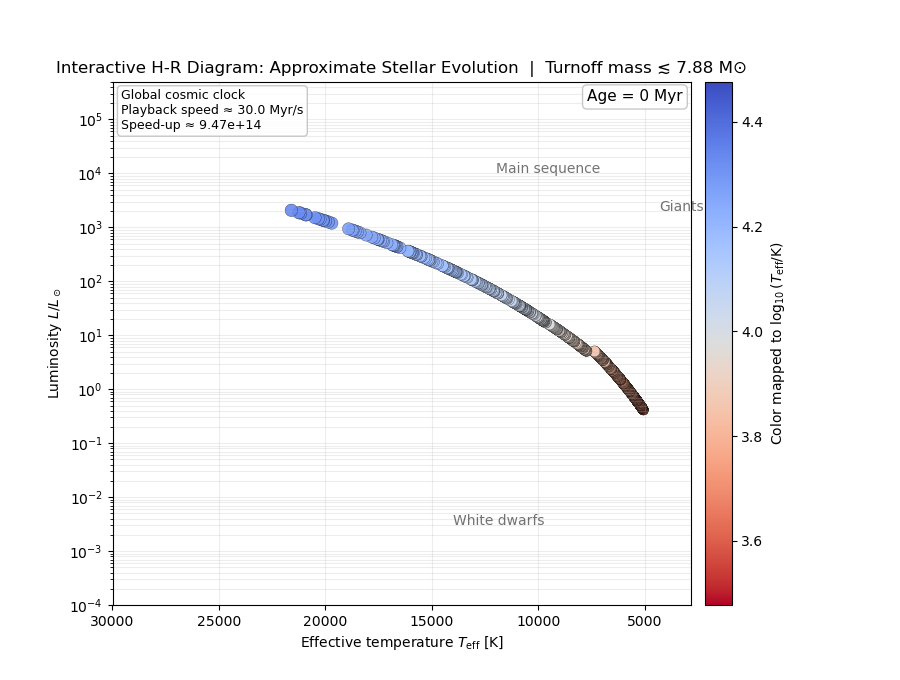

In [2]:
%matplotlib widget
#from hr_evolution_widget import build_hr_widget_demo
ui = build_hr_widget_demo(
    n_stars=1000,
    age_max_myr=3000.0,
    age_step_myr = 0.2,
    playback_duration_s=100.0,
    random_seed=7,
)
display(ui)